In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rsync -a --info=progress2 "/content/drive/MyDrive/Dataset_B/OLD_gt_ferreira_dataset.zip" "/content"

    247,134,906 100%   49.64MB/s    0:00:04 (xfr#1, to-chk=0/1)


In [3]:
import zipfile
with zipfile.ZipFile("OLD_gt_ferreira_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("./dataset/")

In [4]:
#load the modules
import keras
from keras import models, layers
from keras.activations import relu, softmax
from keras.applications import VGG19, VGG16 #trying VGG16 instead
from keras.models import Sequential, load_model, Model
from keras.optimizers import Adam, SGD
from keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Dense, Flatten, GlobalAveragePooling2D
import matplotlib.pyplot as plt
from tensorflow.keras.losses import CategoricalFocalCrossentropy
import sys
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
sys.modules['Image'] = Image

In [5]:
import cv2
#these are pre-processing steps from Ferreira, I'm just making them compatible with preprocessing_function
#adapted from Joshi, P. (2015). OpenCV with Python by example. Packt Publishing Ltd.
def blurpic(img, size):
    kernel_motion_blur = np.zeros((size, size))
    kernel_motion_blur[int((size-1)/2), :] = np.ones(size)
    kernel_motion_blur = kernel_motion_blur / size
    img = cv2.filter2D(img, -1, kernel_motion_blur)
    return img

#function for gaussian noise transformation
def gnoise(img, mean, sd):
    img = img+ np.random.normal(mean,sd, img.shape)
    img = np.clip(img, 0, 255)
    return img

#function for gaussian blur transformation
def gblur(img, size):
    img=cv2.GaussianBlur(img,(size,size),0)
    return img

def combined_preprocessing(img):
    num = np.random.rand()
    if num < 0.30:
        img = blurpic(img, 15)
    elif num >= 0.30:
        img = gnoise(img,15,25)
    elif num >= 0.60 and num < 0.90:
        img = gblur(img, 7)
    else:
        img = blurpic(img, 15)
        img = gnoise(img,15,25)
        img = gblur(img, 7)
    return img

In [6]:
# Keras' data generator can be used to pass the images through the convolutional neural network and apply
#rotation and zoom transformations to the images. Check https://keras.io/preprocessing/image/ for more transformations
from keras.applications.vgg16 import preprocess_input
train_data = ImageDataGenerator(
        rotation_range=40,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.2,
        rescale = 1./255)

train_generator = train_data.flow_from_directory(
        directory=r"./dataset/Train",
        target_size=(224, 224),
        batch_size=8,
        shuffle=True)

Found 9000 images belonging to 10 classes.


In [7]:
#defining the validation data generator
val_data = ImageDataGenerator(rescale = 1./255)

val_generator = val_data.flow_from_directory(
        directory=r"./dataset/Val",
        target_size=(224, 224),
        batch_size=8,
        shuffle=False)

Found 952 images belonging to 10 classes.


In [8]:
vgg19 = VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = vgg19.layers[-1].output
#add dropout and the fully connected layer
x = Dropout(0.2)(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
#add a dense layer with a value equal to the number of classes
predictors = Dense(val_generator.num_classes, activation='softmax')(x)
# Create the model
vgg19model = Model(inputs=vgg19.input, outputs=predictors)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [9]:
"""#Our dataset is imbalanced, ergo, balancing it based on weights
#get the integer labels from the generator
y_train = train_generator.classes
print(train_generator.class_indices)

#get all class indices
classes = np.unique(y_train)

#compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights))

for key, value in class_weights.items():
  if value < 0.5:
    class_weights[key] = 0.5
  if value > 1.0:
    class_weights[key] = 1.5
print(class_weights)"""

"#Our dataset is imbalanced, ergo, balancing it based on weights\n#get the integer labels from the generator\ny_train = train_generator.classes\nprint(train_generator.class_indices)\n\n#get all class indices\nclasses = np.unique(y_train)\n\n#compute class weights\nclass_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)\nclass_weights = dict(zip(classes, class_weights))\n\nfor key, value in class_weights.items():\n  if value < 0.5:\n    class_weights[key] = 0.5\n  if value > 1.0:\n    class_weights[key] = 1.5\nprint(class_weights)"

In [10]:

# define where to save the model after each epoch
filepath = "/content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5"
# add a critera to save only if there was an improvement in the model comparing
# to the previous epoch (in this caset the model is saved if there was a decrease in the loss value)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
# stop training if there is no improvement in model for 10 consecutives epochs.
early_stopping_monitor = EarlyStopping(patience=10)

callbacks_list = [checkpoint, early_stopping_monitor]

In [11]:
# Compile the model
vgg19model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-5),#define the optimizer and the learning rate
              metrics=['acc'])

batch_size=8
epochs=200
model_history=vgg19model.fit(
        train_generator,
        #steps_per_epoch=train_generator.n//batch_size,#unneeded in new keras
        epochs=epochs,
        validation_data=val_generator,
        #validation_steps= val_generator.n//batch_size,#unneeded in new keras
        callbacks=callbacks_list)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - acc: 0.1594 - loss: 2.2892
Epoch 1: val_loss improved from inf to 1.99765, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 287s 234ms/step - acc: 0.1594 - loss: 2.2891 - val_acc: 0.2847 - val_loss: 1.9976
Epoch 2/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - acc: 0.4701 - loss: 1.5646
Epoch 2: val_loss improved from 1.99765 to 1.50845, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 253s 225ms/step - acc: 0.4701 - loss: 1.5644 - val_acc: 0.5032 - val_loss: 1.5084
Epoch 3/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - acc: 0.7179 - loss: 0.8495
Epoch 3: val_loss improved from 1.50845 to 0.91551, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 254s 226ms/step - acc: 0.7179 - loss: 0.8494 - val_acc: 0.7143 - val_loss: 0.9155
Epoch 4/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - acc: 0.8035 - loss: 0.5920
Epoch 4: val_loss improved from 0.91551 to 0.89224, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 254s 226ms/step - acc: 0.8035 - loss: 0.5919 - val_acc: 0.7132 - val_loss: 0.8922
Epoch 5/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - acc: 0.8453 - loss: 0.4689
Epoch 5: val_loss did not improve from 0.89224
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 250s 222ms/step - acc: 0.8453 - loss: 0.4689 - val_acc: 0.7321 - val_loss: 0.9163
Epoch 6/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - acc: 0.8711 - loss: 0.3917
Epoch 6: val_loss improved from 0.89224 to 0.76781, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 254s 226ms/step - acc: 0.8711 - loss: 0.3917 - val_acc: 0.7679 - val_loss: 0.7678
Epoch 7/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - acc: 0.8861 - loss: 0.3570
Epoch 7: val_loss improved from 0.76781 to 0.63354, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 256s 228ms/step - acc: 0.8861 - loss: 0.3570 - val_acc: 0.8214 - val_loss: 0.6335
Epoch 8/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - acc: 0.9017 - loss: 0.3011
Epoch 8: val_loss improved from 0.63354 to 0.57848, saving model to /content/drive/MyDrive/CNN_Ferreira_Experiment/OLD_data/saved_model.h5


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 257s 228ms/step - acc: 0.9017 - loss: 0.3011 - val_acc: 0.8099 - val_loss: 0.5785
Epoch 9/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - acc: 0.9058 - loss: 0.2800
Epoch 9: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 247s 220ms/step - acc: 0.9058 - loss: 0.2800 - val_acc: 0.7794 - val_loss: 0.7892
Epoch 10/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - acc: 0.9191 - loss: 0.2536
Epoch 10: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 249s 221ms/step - acc: 0.9191 - loss: 0.2536 - val_acc: 0.8046 - val_loss: 0.7363
Epoch 11/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - acc: 0.9128 - loss: 0.2550
Epoch 11: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 247s 219ms/step - acc: 0.9128 - loss: 0.2550 - val_acc: 0.7815 - val_loss: 0.7616
Epoch 12/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - acc: 0.9298 - loss: 0.2079
Epoch 12: val_loss did not improve from 0.57848
1125/1125 

In [12]:
#load the model
model=load_model(filepath)

#check the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,78

 Total params: 26,449,740 (100.90 MB)

 Trainable params: 26,449,738 (100.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [13]:

# Compile the model
model.compile(loss='categorical_crossentropy',
             optimizer=SGD(learning_rate=1e-6),
             metrics=['acc'])

#train the model
model_history_2=model.fit(
        train_generator,
        #steps_per_epoch=train_generator.n//batch_size, #keras can now infer this from train_generator length
        epochs=200,
        validation_data=val_generator,
        #validation_steps= val_generator.n//batch_size, #keras can infer this now
        callbacks=callbacks_list)

Epoch 1/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - acc: 0.9041 - loss: 0.2825
Epoch 1: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 216s 188ms/step - acc: 0.9041 - loss: 0.2825 - val_acc: 0.8078 - val_loss: 0.5943
Epoch 2/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - acc: 0.9213 - loss: 0.2500
Epoch 2: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 208s 185ms/step - acc: 0.9213 - loss: 0.2500 - val_acc: 0.8067 - val_loss: 0.6002
Epoch 3/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - acc: 0.9252 - loss: 0.2404
Epoch 3: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 208s 185ms/step - acc: 0.9252 - loss: 0.2404 - val_acc: 0.8004 - val_loss: 0.6146
Epoch 4/200
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - acc: 0.9264 - loss: 0.2320
Epoch 4: val_loss did not improve from 0.57848
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 208s 185ms/step - acc: 0.9264 - loss: 0.2320 - val_acc: 0.8004 - val_loss: 0.6196
Epoch 5/200
1125

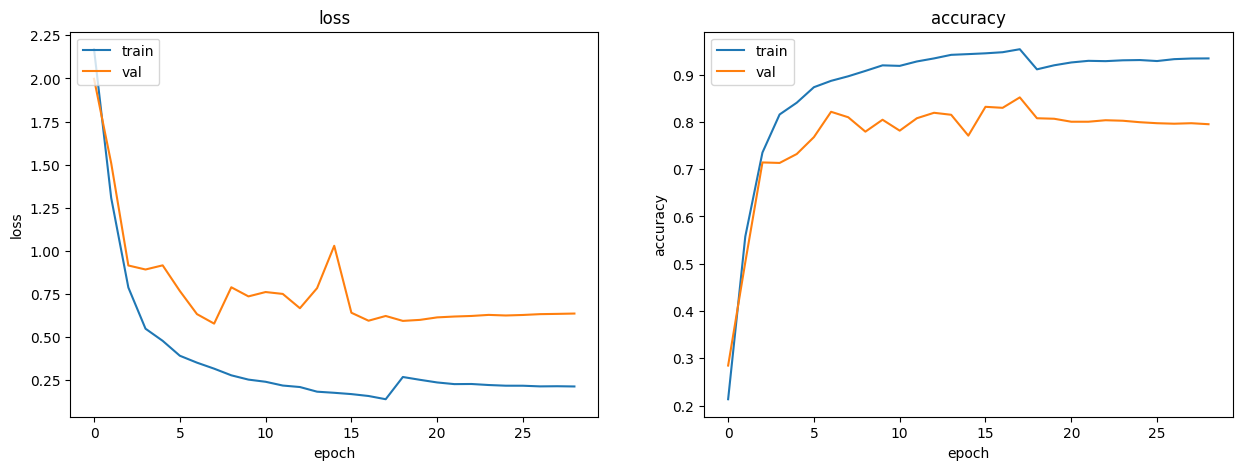

In [14]:
#size of the plots
fig=plt.figure(figsize=(15,5))
columns = 2
rows = 1

#plot loss
#the accuracy and loss are stored in the "model_history"
fig.add_subplot(rows, columns, 1)
plt.plot(model_history.history['loss']+ model_history_2.history['loss']) #merge the loss from the two training steps
plt.plot(model_history.history['val_loss']+ model_history_2.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

#plot accuracy
fig.add_subplot(rows, columns, 2)
plt.plot(model_history.history['acc']+ model_history_2.history['acc'])
plt.plot(model_history.history['val_acc']+ model_history_2.history['val_acc'])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [17]:
#load the best saved trained model
#REMEMBER TO RUN THIS IN THE MORNING!!!
#REMEMBER THAT THE ACC YOU GET IS FROM THE ADAM MODEL AND NOT THE ONE FINE-TUNED WITH SGD!
#BECAUSE YOU FORGOT TO INCLUDE THIS CEL!
model=load_model(filepath)

In [18]:
val_sony_datagen1 = ImageDataGenerator(rescale = 1./255)
val_sony_datagen = val_sony_datagen1.flow_from_directory(
        directory=r"./dataset/Test", #This folder should contain pictures of each bird in a different subfolder (similar to the training data set)
        target_size=(224, 224),
        batch_size=142,#number of images in the testing dataset
        shuffle=False)

#load the pictures in the testing folder. The x_batch contains the pictures and the y_batch contains the
#identities of the individuals
x_batch, y_batch=next(val_sony_datagen)

#create lists to store the right and the wrong classifications
right_classification=[]
wrong_classification=[]
#loop through all the testing pictures and predict the identity of the individuals
for i in range(0,len(x_batch)):
    image=np.expand_dims(x_batch[i], axis=0)
    result=model.predict(image)
    #if the predicted identity matches the real identity (from the y_batch) store the
    #index of this pcitures in the right classification list. If different store it
    #in the wrong classification list
    if np.where(y_batch[i] == np.amax(y_batch[i]))[0][0]==np.where(result == np.amax(result))[1][0]:
        right_classification.append(i)
    else:
        wrong_classification.append(i)
#print the results
print(len(right_classification)/(len(wrong_classification)+len(right_classification)))

Found 142 images belonging to 10 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━

In [17]:
!rsync -a --info=progress2 "/content/drive/MyDrive/Dataset_B/Org_Test_Ferreira.zip" "/content"

      2,110,101 100%   30.48MB/s    0:00:00 (xfr#1, to-chk=0/1)


In [18]:
import zipfile
with zipfile.ZipFile("Org_Test_Ferreira.zip", 'r') as zip_ref:
    zip_ref.extractall("./dataset-test/")

In [26]:
!ls dataset

Test  Train  Val


In [20]:
!ls

Test
